
--- Generating Graph 1 ---

Graph 1 Insights:
- Nodes: 50
- Edges: 113
- Density: 0.0922
- Diameter: 5
- Avg Clustering Coefficient: 0.0929
- Detected Communities: 4
- Community Sizes: [41, 5, 3, 1]
-  Anomalies Detected: 1 → [3]
-  Articulation Points Detected: 3 → [4, 14, 16]
-  Top Hubs per Community:
  Community 1: [3]
  Community 2: [8]
  Community 3: [4]
  Community 4: [43]


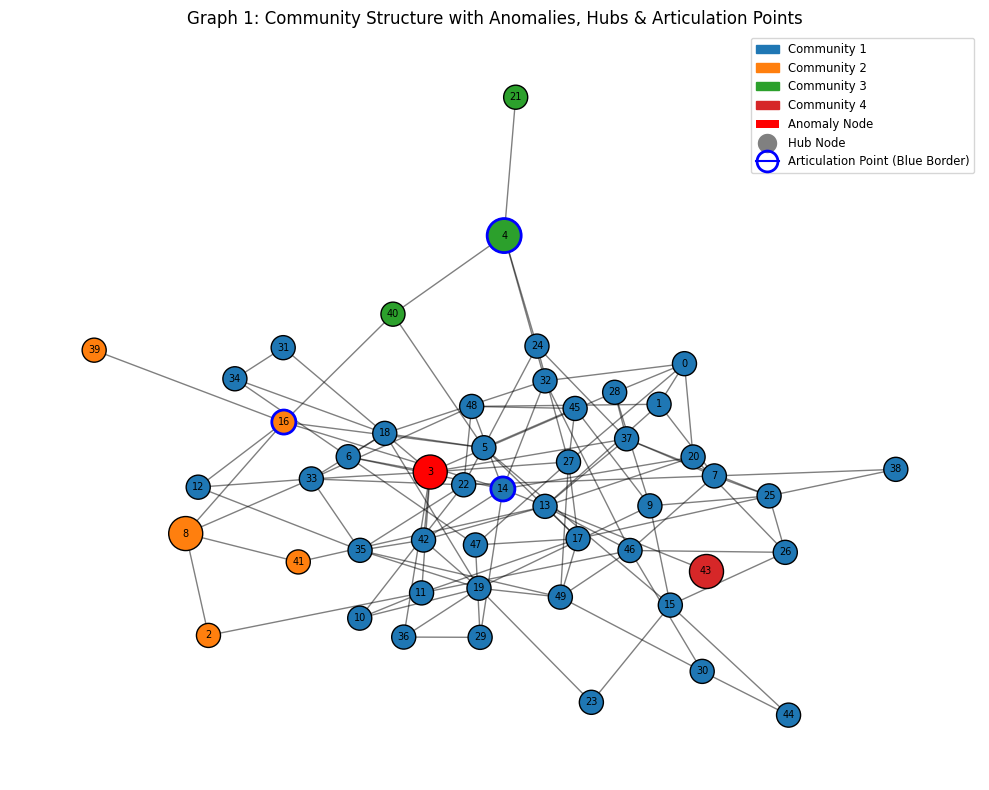

C:\Users\Manan Sharma\AppData\Local\Temp\ipykernel_21228\119002840.py:155: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


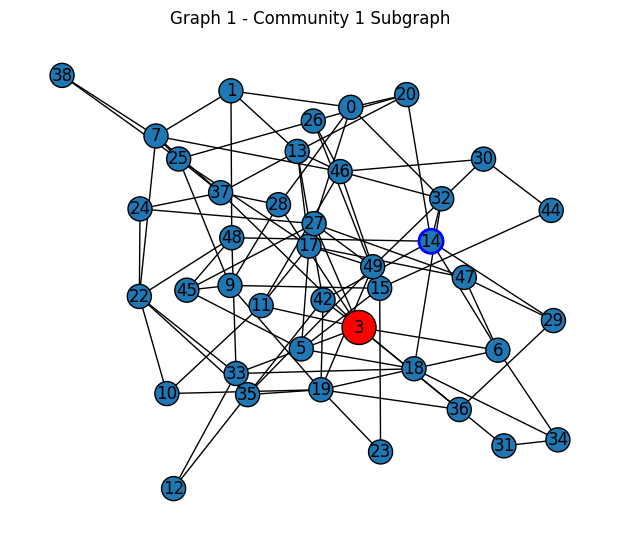

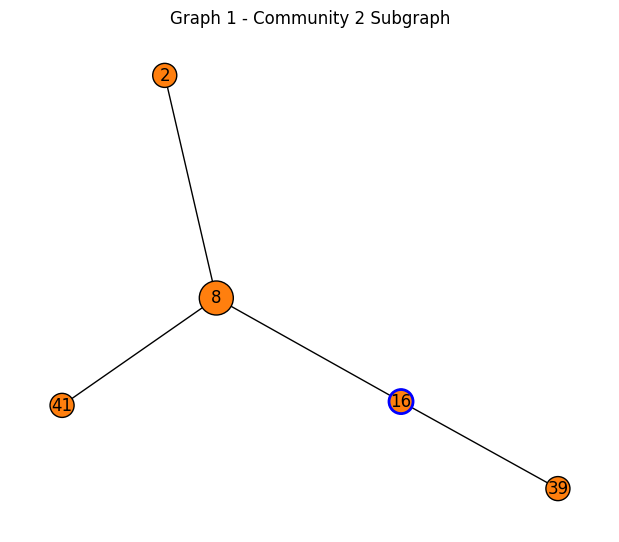

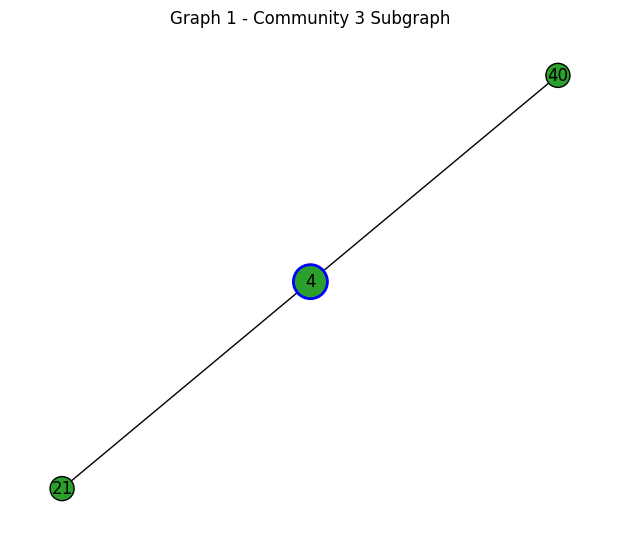

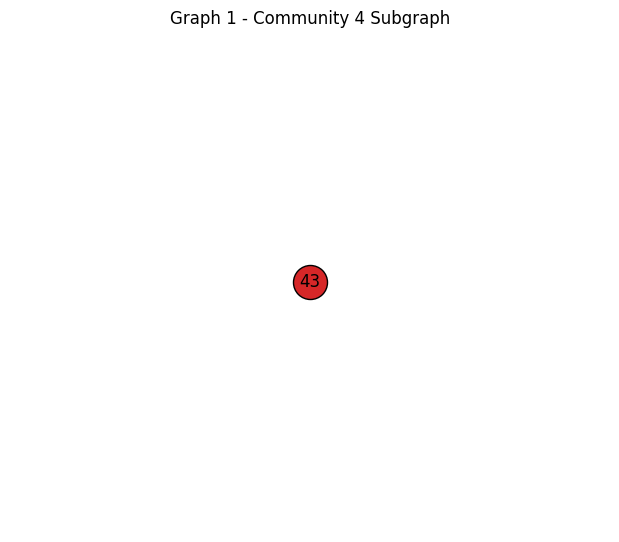


--- Generating Graph 2 ---

Graph 2 Insights:
- Nodes: 50
- Edges: 108
- Density: 0.0882
- Diameter: 5
- Avg Clustering Coefficient: 0.0500
- Detected Communities: 4
- Community Sizes: [25, 17, 5, 3]
-  Anomalies Detected: 3 → [0, 4, 13]
-  Articulation Points Detected: 2 → [25, 29]
-  Top Hubs per Community:
  Community 1: [0]
  Community 2: [42]
  Community 3: [3]
  Community 4: [7]


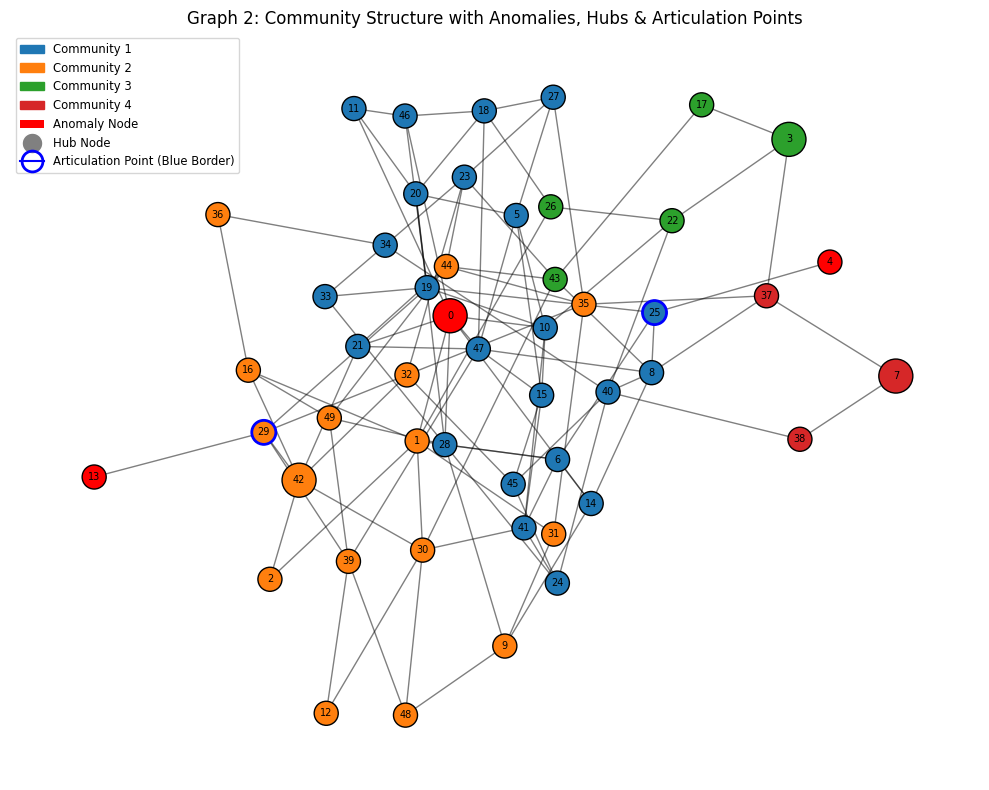

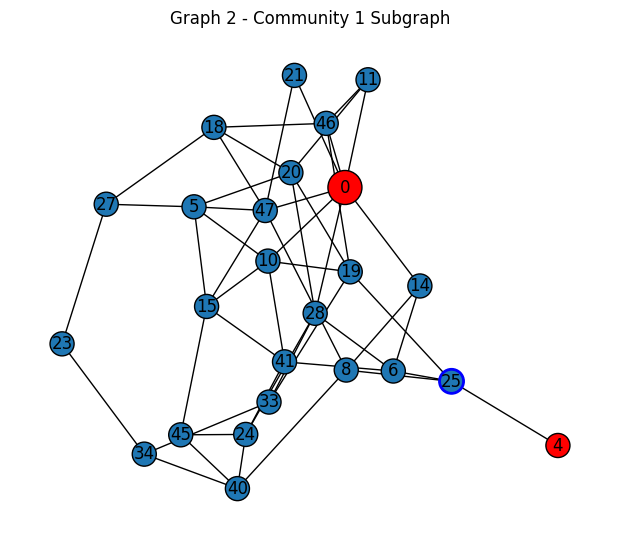

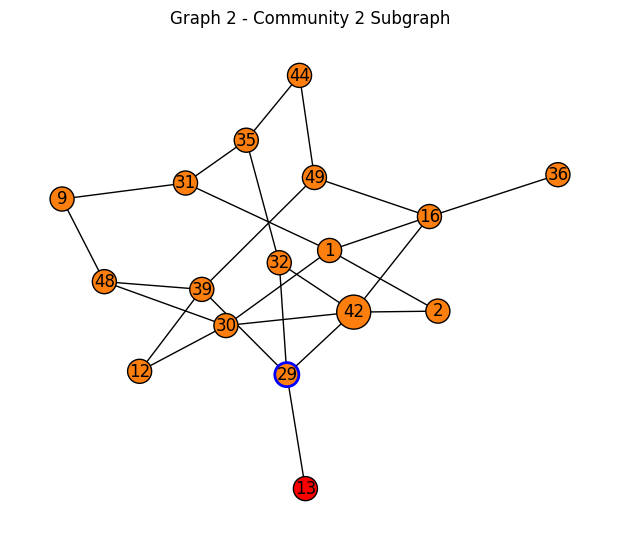

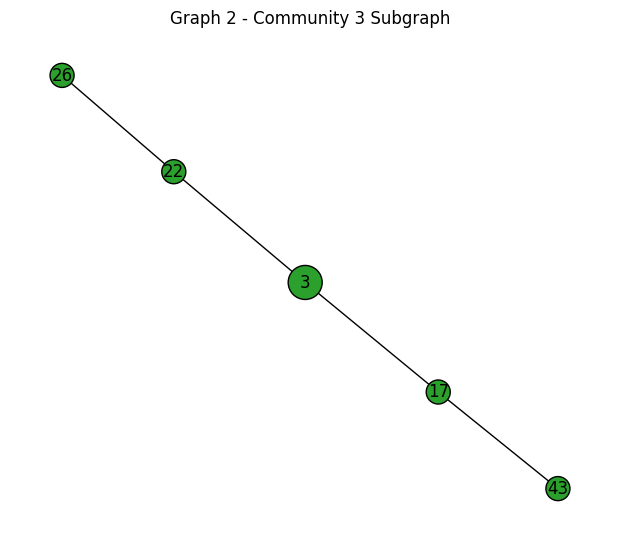

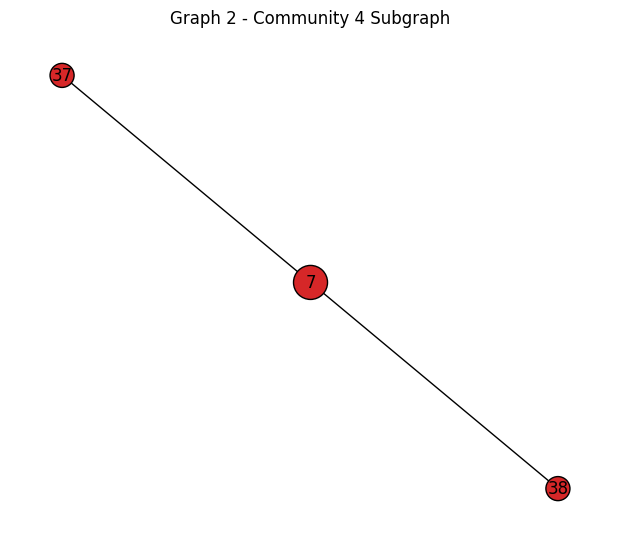


--- Generating Graph 3 ---

Graph 3 Insights:
- Nodes: 50
- Edges: 101
- Density: 0.0824
- Diameter: 6
- Avg Clustering Coefficient: 0.0841
- Detected Communities: 4
- Community Sizes: [32, 10, 4, 4]
-  Anomalies Detected: 0 → []
-  Articulation Points Detected: 3 → [39, 37, 1]
-  Top Hubs per Community:
  Community 1: [4]
  Community 2: [39]
  Community 3: [40]
  Community 4: [37]


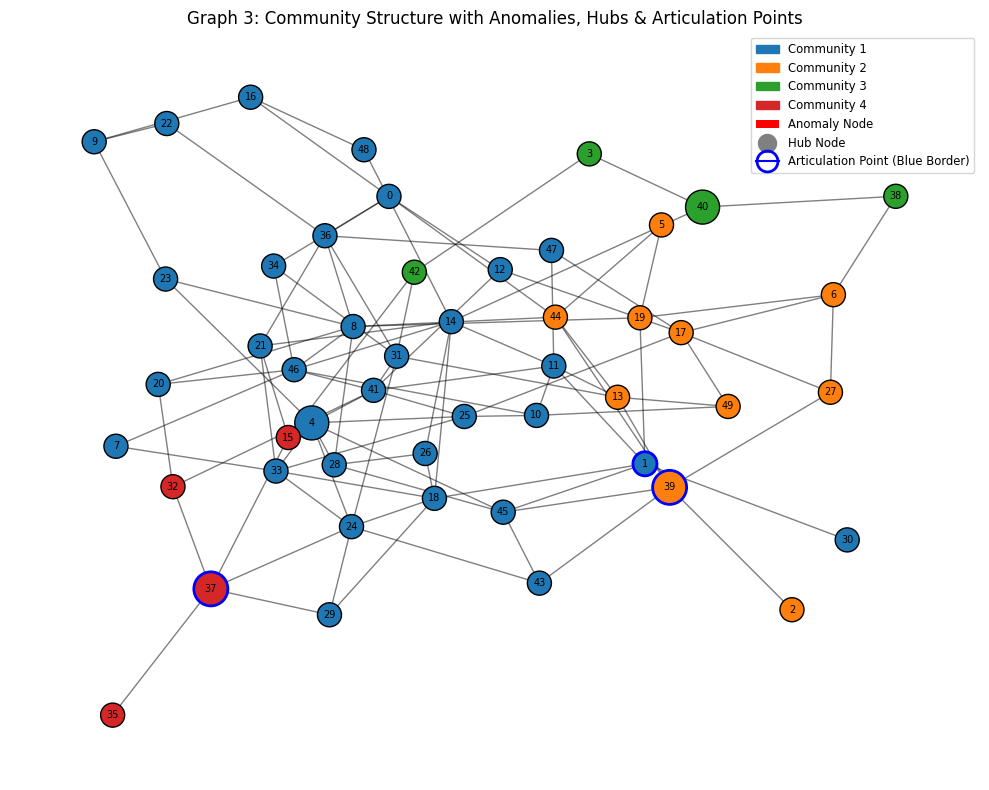

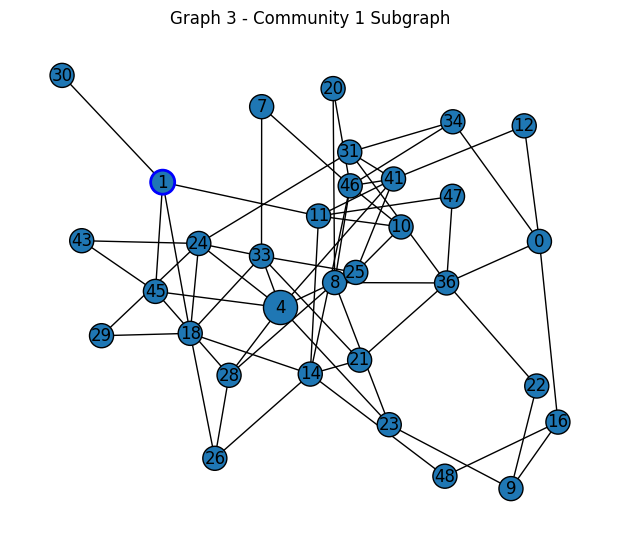

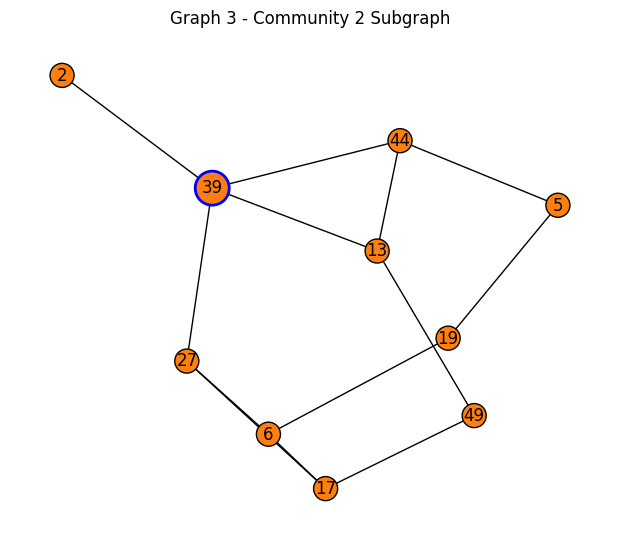

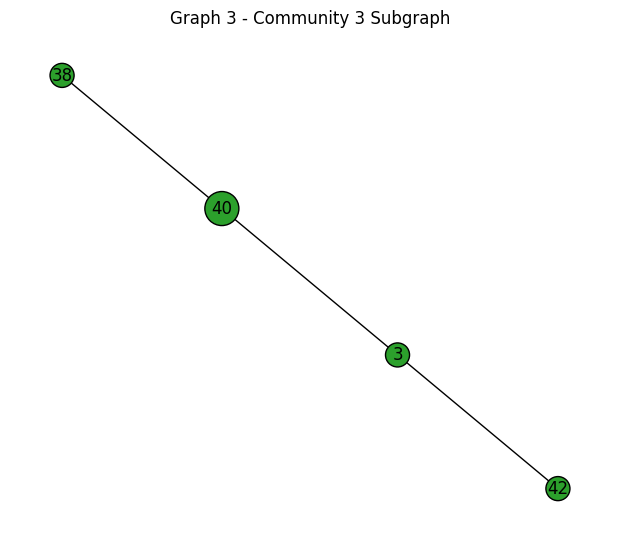

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import random
import numpy as np
from networkx.algorithms import community
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# 1. Generate Random Connected Graph
def generate_random_social_network(n_nodes=50, p_edge=0.05):
    G = nx.erdos_renyi_graph(n=n_nodes, p=p_edge, seed=random.randint(0, 1000))
    while not nx.is_connected(G):
        G = nx.erdos_renyi_graph(n=n_nodes, p=p_edge, seed=random.randint(0, 1000))
    return G

# 2. Community Detection
def detect_communities_girvan_newman(G, n_communities=3):
    comp = community.girvan_newman(G)
    limited = next(comp)
    for _ in range(n_communities - 2):
        try:
            limited = next(comp)
        except StopIteration:
            break
    communities = [list(c) for c in limited]
    return communities

# 3. Anomaly Detection (Simple example using degree outliers)
def detect_anomalies(G):
    degrees = np.array([val for (node, val) in G.degree()])
    mean, std = degrees.mean(), degrees.std()
    anomalies = [node for node, deg in G.degree() if deg > mean + 2 * std or deg < mean - 2 * std]
    return anomalies

# 4. Identify Hubs in Each Community
def identify_hubs_in_communities(G, communities, top_n=1):
    hubs_by_community = []
    for comm in communities:
        subgraph = G.subgraph(comm)
        centrality = nx.degree_centrality(subgraph)
        sorted_nodes = sorted(centrality.items(), key=lambda x: x[1], reverse=True)
        hubs = [node for node, _ in sorted_nodes[:top_n]]
        hubs_by_community.append(hubs)
    return hubs_by_community

# 5. Detect Articulation Points
def detect_articulation_points(G):
    return list(nx.articulation_points(G))

# 6. Print Graph Insights
def print_graph_insights(G, communities, idx, anomalies, hubs_by_community, aps):
    print(f"\nGraph {idx + 1} Insights:")
    print(f"- Nodes: {G.number_of_nodes()}")
    print(f"- Edges: {G.number_of_edges()}")
    print(f"- Density: {nx.density(G):.4f}")
    print(f"- Diameter: {nx.diameter(G)}")
    print(f"- Avg Clustering Coefficient: {nx.average_clustering(G):.4f}")
    print(f"- Detected Communities: {len(communities)}")
    print("- Community Sizes:", [len(c) for c in communities])
    print(f"-  Anomalies Detected: {len(anomalies)} → {anomalies}")
    print(f"-  Articulation Points Detected: {len(aps)} → {aps}")
    print(f"-  Top Hubs per Community:")
    for i, hubs in enumerate(hubs_by_community):
        print(f"  Community {i + 1}: {hubs}")

# 7. Plot Graph with Communities, Hubs, Anomalies, and Articulation Points (Dual Encoding + Legend)
def plot_graph_with_communities(G, communities, anomalies, hubs_by_community, aps, idx):
    pos = nx.spring_layout(G, seed=42)
    colors = [f"C{i}" for i in range(len(communities))]
    plt.figure(figsize=(10, 8))

    community_patches = []
    for i, comm in enumerate(communities):
        node_colors = []
        node_sizes = []
        border_nodes = []

        for node in comm:
            if node in anomalies:
                node_colors.append('red')
            else:
                node_colors.append(colors[i])

            if node in hubs_by_community[i]:
                node_sizes.append(600)
            else:
                node_sizes.append(300)

            if node in aps:
                border_nodes.append(node)

        nx.draw_networkx_nodes(
            G, pos, nodelist=comm, node_color=node_colors,
            node_size=node_sizes, edgecolors='black'
        )

        # Blue border for articulation points
        if border_nodes:
            border_sizes = [node_sizes[comm.index(n)] for n in border_nodes]
            nx.draw_networkx_nodes(
                G, pos, nodelist=border_nodes, node_color='none',
                node_size=border_sizes, edgecolors='blue', linewidths=2
            )

        community_patches.append(Patch(color=colors[i], label=f"Community {i + 1}"))

    nx.draw_networkx_edges(G, pos, alpha=0.5)
    nx.draw_networkx_labels(G, pos, font_size=7)

    # Additional role-based legend entries
    legend_elements = community_patches + [
        Patch(facecolor='red', label='Anomaly Node'),
        Line2D([0], [0], marker='o', color='w', label='Hub Node', markerfacecolor='gray', markersize=15),
        Line2D([0], [0], marker='o', color='blue', label='Articulation Point (Blue Border)', markerfacecolor='none', markersize=15, markeredgewidth=2),
    ]

    plt.legend(handles=legend_elements, loc='best', fontsize='small')
    plt.title(f"Graph {idx + 1}: Community Structure with Anomalies, Hubs & Articulation Points")
    plt.axis('off')
    plt.tight_layout()
    plt.show()

# 8. Plot Subgraphs for Each Community
def plot_community_subgraphs(G, communities, anomalies, hubs_by_community, aps, graph_idx):
    for i, comm in enumerate(communities):
        subgraph = G.subgraph(comm)
        pos = nx.spring_layout(subgraph, seed=42)
        node_colors = []
        node_sizes = []
        border_nodes = []

        for node in subgraph.nodes():
            if node in anomalies:
                node_colors.append("red")
            else:
                node_colors.append(f"C{i}")

            if node in hubs_by_community[i]:
                node_sizes.append(600)
            else:
                node_sizes.append(300)

            if node in aps:
                border_nodes.append(node)

        plt.figure(figsize=(6, 5))
        nx.draw(subgraph, pos, with_labels=True, node_color=node_colors, node_size=node_sizes, edgecolors='black')

        if border_nodes:
            border_sizes = [node_sizes[list(subgraph.nodes()).index(n)] for n in border_nodes]
            nx.draw_networkx_nodes(subgraph, pos, nodelist=border_nodes, node_color='none', node_size=border_sizes, edgecolors='blue', linewidths=2)

        plt.title(f"Graph {graph_idx + 1} - Community {i + 1} Subgraph")
        plt.axis('off')
        plt.tight_layout()
        plt.show()

# 9. Main Execution
def main():
    n_graphs = 3
    for idx in range(n_graphs):
        print(f"\n--- Generating Graph {idx + 1} ---")
        G = generate_random_social_network(n_nodes=50, p_edge=0.08)
        communities = detect_communities_girvan_newman(G, n_communities=4)
        anomalies = detect_anomalies(G)
        hubs_by_community = identify_hubs_in_communities(G, communities, top_n=1)
        aps = detect_articulation_points(G)

        print_graph_insights(G, communities, idx, anomalies, hubs_by_community, aps)
        plot_graph_with_communities(G, communities, anomalies, hubs_by_community, aps, idx)
        plot_community_subgraphs(G, communities, anomalies, hubs_by_community, aps, idx)

if __name__ == "__main__":
    main()



--- Generating Graph 1 ---

Graph 1 Insights:
- Nodes: 50
- Edges: 113
- Density: 0.0922
- Diameter: 5
- Avg Clustering Coefficient: 0.0929
- Detected Communities: 4
- Community Sizes: [41, 5, 3, 1]
-  Anomalies Detected: 1 → [3]
-  Articulation Points Detected: 3 → [4, 14, 16]
-  Top Hubs per Community:
  Community 1: [3]
  Community 2: [8]
  Community 3: [4]
  Community 4: [43]


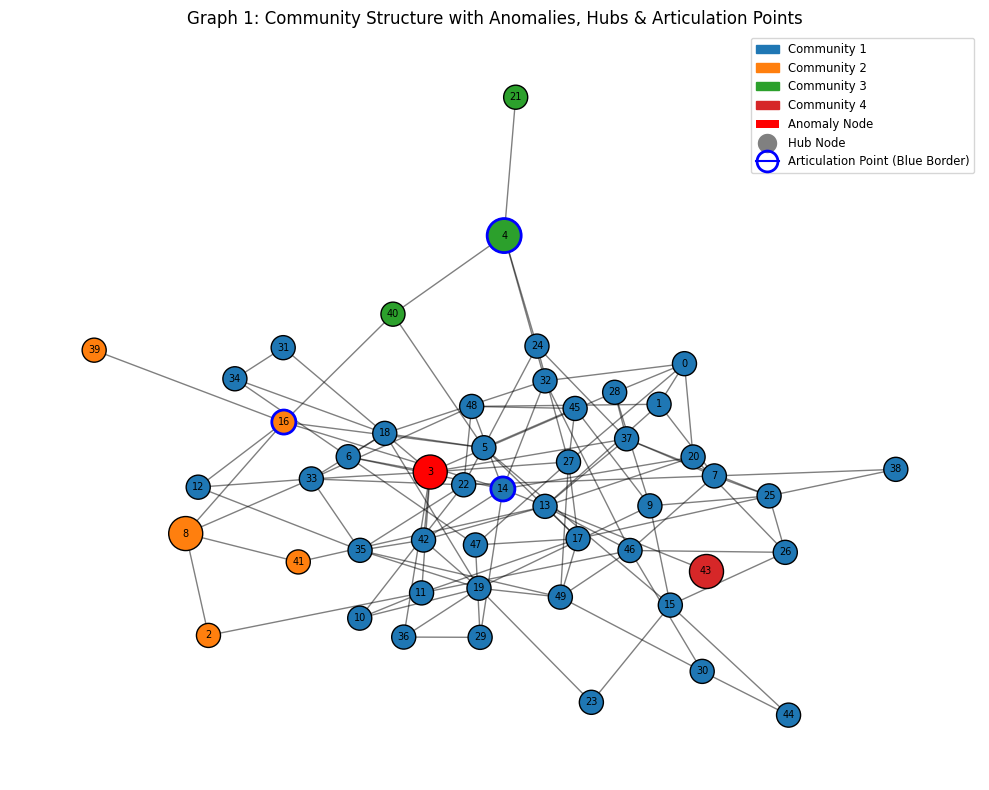

C:\Users\Manan Sharma\AppData\Local\Temp\ipykernel_21228\119002840.py:155: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


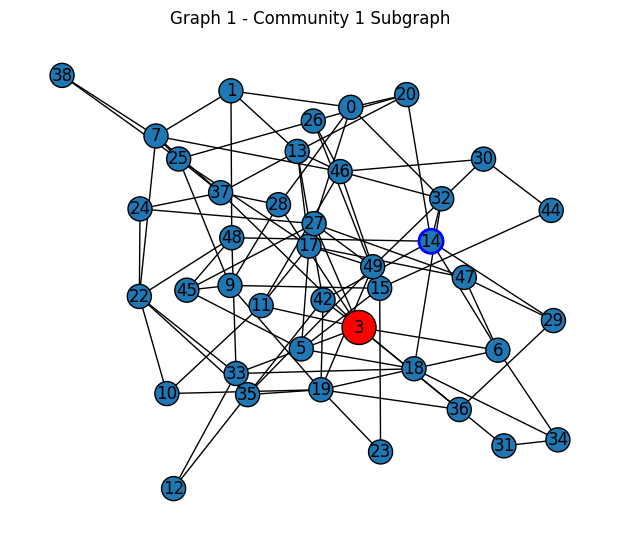

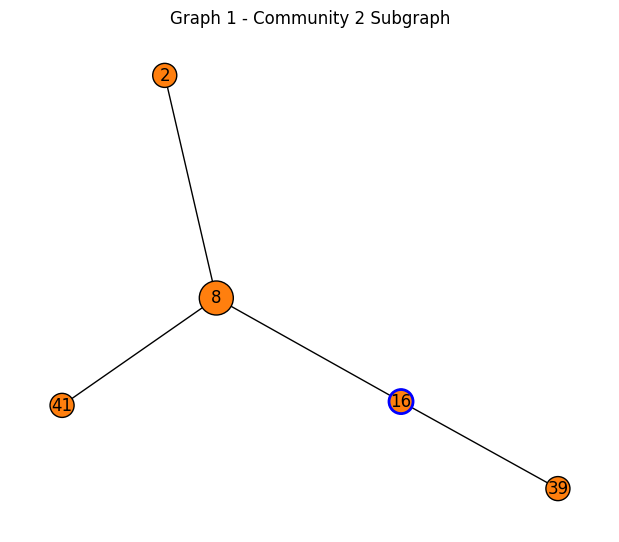

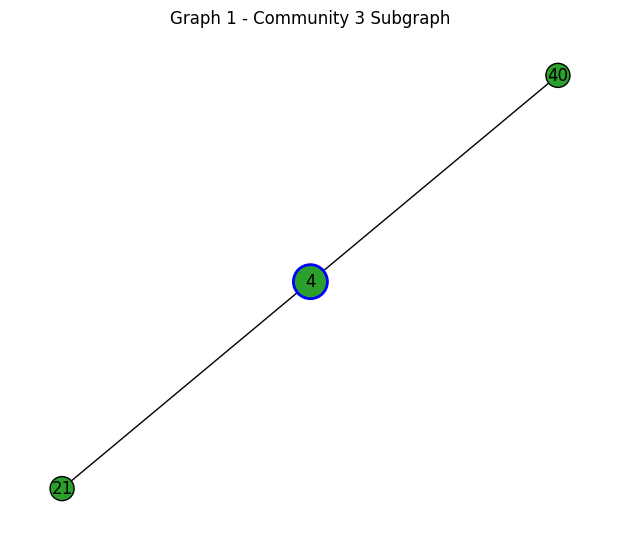

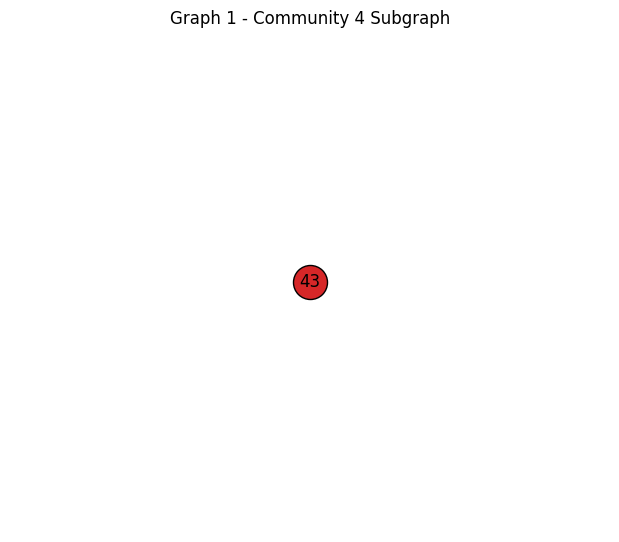


--- Generating Graph 2 ---

Graph 2 Insights:
- Nodes: 50
- Edges: 108
- Density: 0.0882
- Diameter: 5
- Avg Clustering Coefficient: 0.0500
- Detected Communities: 4
- Community Sizes: [25, 17, 5, 3]
-  Anomalies Detected: 3 → [0, 4, 13]
-  Articulation Points Detected: 2 → [25, 29]
-  Top Hubs per Community:
  Community 1: [0]
  Community 2: [42]
  Community 3: [3]
  Community 4: [7]


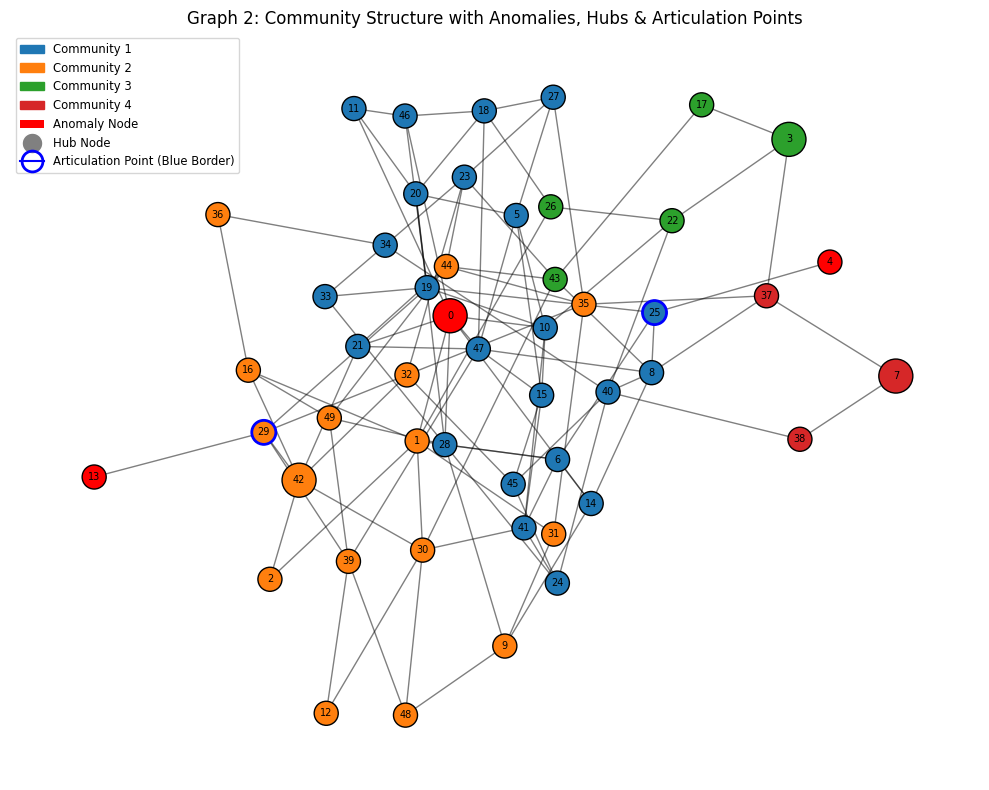

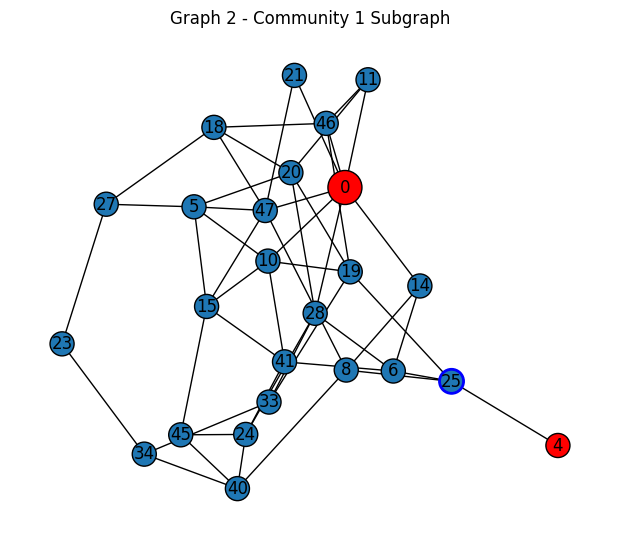

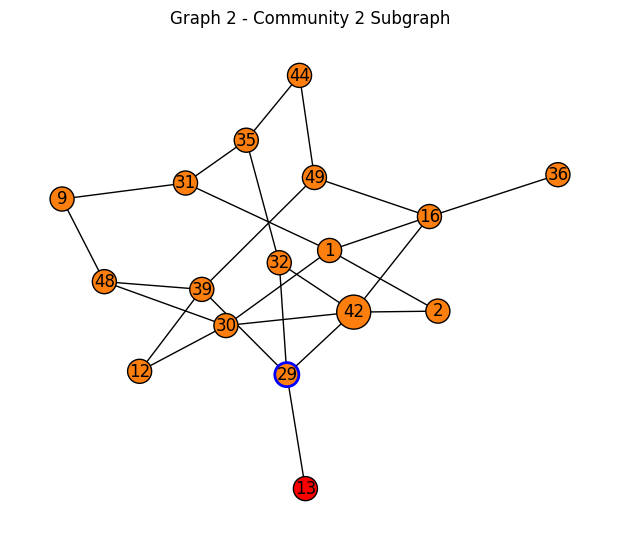

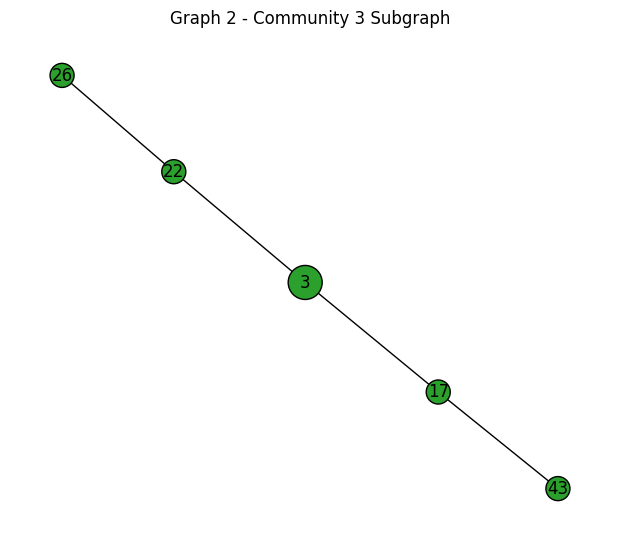

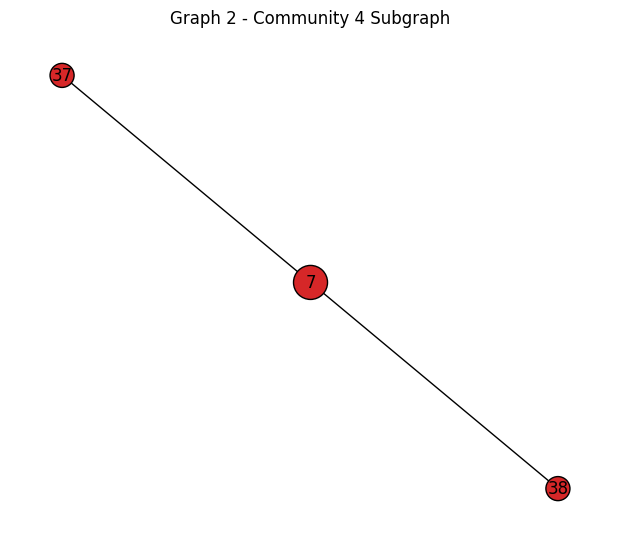


--- Generating Graph 3 ---

Graph 3 Insights:
- Nodes: 50
- Edges: 101
- Density: 0.0824
- Diameter: 6
- Avg Clustering Coefficient: 0.0841
- Detected Communities: 4
- Community Sizes: [32, 10, 4, 4]
-  Anomalies Detected: 0 → []
-  Articulation Points Detected: 3 → [39, 37, 1]
-  Top Hubs per Community:
  Community 1: [4]
  Community 2: [39]
  Community 3: [40]
  Community 4: [37]


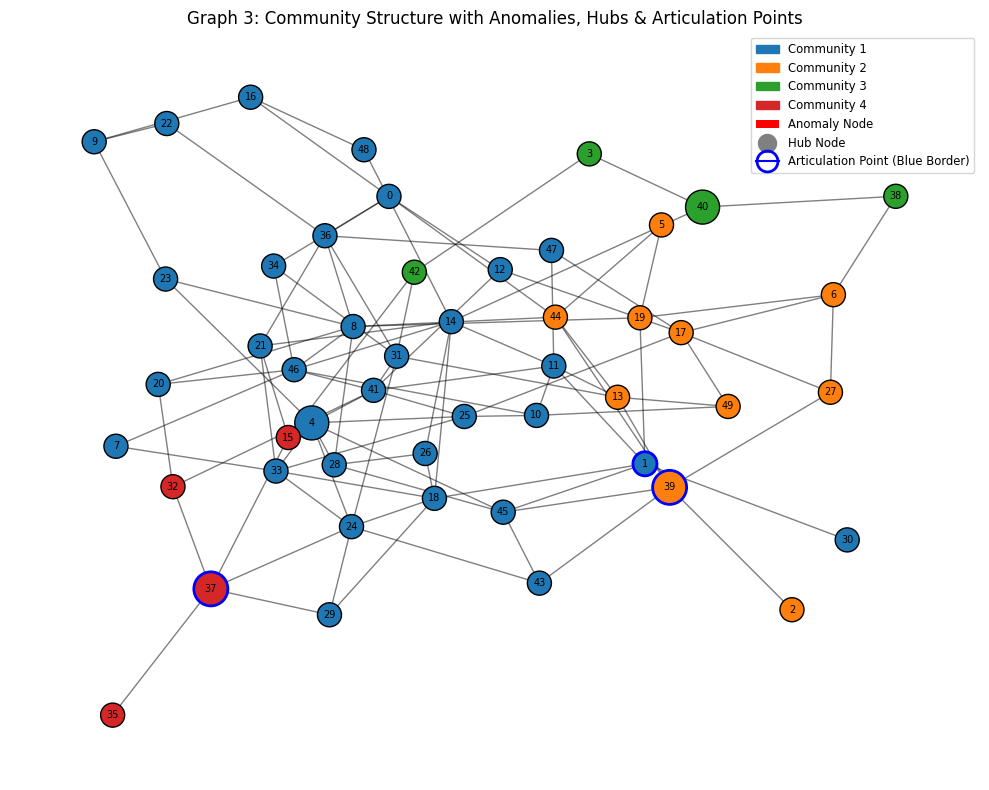

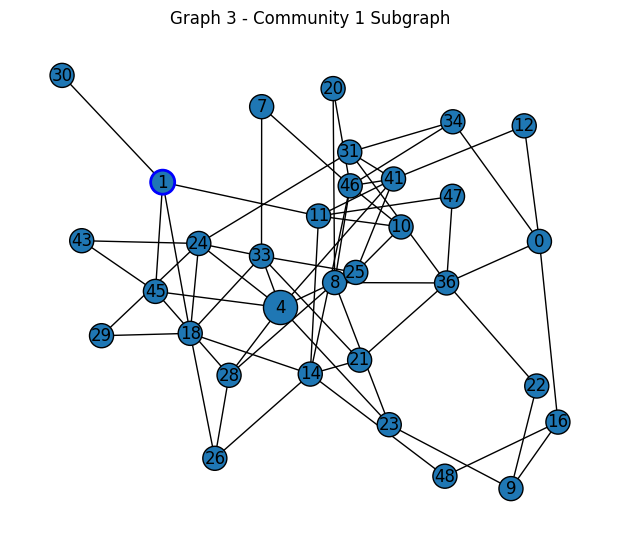

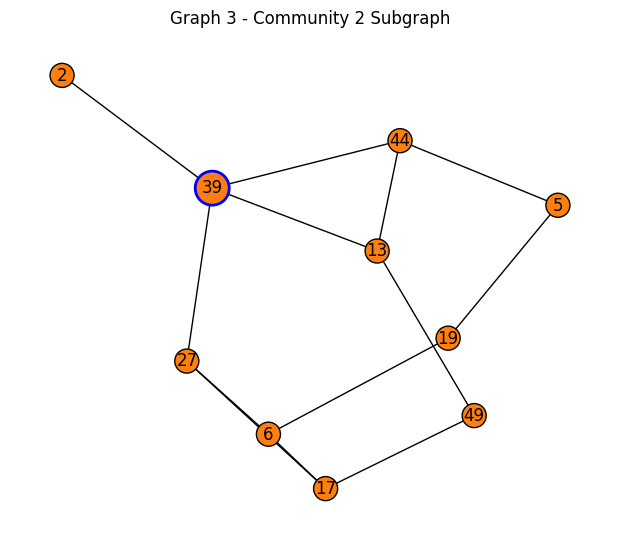

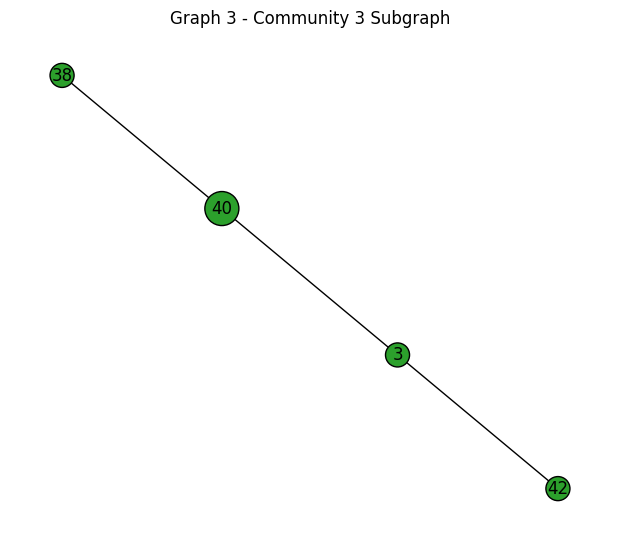

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import random
import numpy as np
from networkx.algorithms import community
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# 1. Generate Random Connected Graph
def generate_random_social_network(n_nodes=50, p_edge=0.05):
    G = nx.erdos_renyi_graph(n=n_nodes, p=p_edge, seed=random.randint(0, 1000))
    while not nx.is_connected(G):
        G = nx.erdos_renyi_graph(n=n_nodes, p=p_edge, seed=random.randint(0, 1000))
    return G

# 2. Community Detection
def detect_communities_girvan_newman(G, n_communities=3):
    comp = community.girvan_newman(G)
    limited = next(comp)
    for _ in range(n_communities - 2):
        try:
            limited = next(comp)
        except StopIteration:
            break
    communities = [list(c) for c in limited]
    return communities

# 3. Anomaly Detection (Simple example using degree outliers)
def detect_anomalies(G):
    degrees = np.array([val for (node, val) in G.degree()])
    mean, std = degrees.mean(), degrees.std()
    anomalies = [node for node, deg in G.degree() if deg > mean + 2 * std or deg < mean - 2 * std]
    return anomalies

# 4. Identify Hubs in Each Community
def identify_hubs_in_communities(G, communities, top_n=1):
    hubs_by_community = []
    for comm in communities:
        subgraph = G.subgraph(comm)
        centrality = nx.degree_centrality(subgraph)
        sorted_nodes = sorted(centrality.items(), key=lambda x: x[1], reverse=True)
        hubs = [node for node, _ in sorted_nodes[:top_n]]
        hubs_by_community.append(hubs)
    return hubs_by_community

# 5. Detect Articulation Points
def detect_articulation_points(G):
    return list(nx.articulation_points(G))

# 6. Print Graph Insights
def print_graph_insights(G, communities, idx, anomalies, hubs_by_community, aps):
    print(f"\nGraph {idx + 1} Insights:")
    print(f"- Nodes: {G.number_of_nodes()}")
    print(f"- Edges: {G.number_of_edges()}")
    print(f"- Density: {nx.density(G):.4f}")
    print(f"- Diameter: {nx.diameter(G)}")
    print(f"- Avg Clustering Coefficient: {nx.average_clustering(G):.4f}")
    print(f"- Detected Communities: {len(communities)}")
    print("- Community Sizes:", [len(c) for c in communities])
    print(f"-  Anomalies Detected: {len(anomalies)} → {anomalies}")
    print(f"-  Articulation Points Detected: {len(aps)} → {aps}")
    print(f"-  Top Hubs per Community:")
    for i, hubs in enumerate(hubs_by_community):
        print(f"  Community {i + 1}: {hubs}")

# 7. Plot Graph with Communities, Hubs, Anomalies, and Articulation Points (Dual Encoding + Legend)
def plot_graph_with_communities(G, communities, anomalies, hubs_by_community, aps, idx):
    pos = nx.spring_layout(G, seed=42)
    colors = [f"C{i}" for i in range(len(communities))]
    plt.figure(figsize=(10, 8))

    community_patches = []
    for i, comm in enumerate(communities):
        node_colors = []
        node_sizes = []
        border_nodes = []

        for node in comm:
            if node in anomalies:
                node_colors.append('red')
            else:
                node_colors.append(colors[i])

            if node in hubs_by_community[i]:
                node_sizes.append(600)
            else:
                node_sizes.append(300)

            if node in aps:
                border_nodes.append(node)

        nx.draw_networkx_nodes(
            G, pos, nodelist=comm, node_color=node_colors,
            node_size=node_sizes, edgecolors='black'
        )

        # Blue border for articulation points
        if border_nodes:
            border_sizes = [node_sizes[comm.index(n)] for n in border_nodes]
            nx.draw_networkx_nodes(
                G, pos, nodelist=border_nodes, node_color='none',
                node_size=border_sizes, edgecolors='blue', linewidths=2
            )

        community_patches.append(Patch(color=colors[i], label=f"Community {i + 1}"))

    nx.draw_networkx_edges(G, pos, alpha=0.5)
    nx.draw_networkx_labels(G, pos, font_size=7)

    # Additional role-based legend entries
    legend_elements = community_patches + [
        Patch(facecolor='red', label='Anomaly Node'),
        Line2D([0], [0], marker='o', color='w', label='Hub Node', markerfacecolor='gray', markersize=15),
        Line2D([0], [0], marker='o', color='blue', label='Articulation Point (Blue Border)', markerfacecolor='none', markersize=15, markeredgewidth=2),
    ]

    plt.legend(handles=legend_elements, loc='best', fontsize='small')
    plt.title(f"Graph {idx + 1}: Community Structure with Anomalies, Hubs & Articulation Points")
    plt.axis('off')
    plt.tight_layout()
    plt.show()

# 8. Plot Subgraphs for Each Community
def plot_community_subgraphs(G, communities, anomalies, hubs_by_community, aps, graph_idx):
    for i, comm in enumerate(communities):
        subgraph = G.subgraph(comm)
        pos = nx.spring_layout(subgraph, seed=42)
        node_colors = []
        node_sizes = []
        border_nodes = []

        for node in subgraph.nodes():
            if node in anomalies:
                node_colors.append("red")
            else:
                node_colors.append(f"C{i}")

            if node in hubs_by_community[i]:
                node_sizes.append(600)
            else:
                node_sizes.append(300)

            if node in aps:
                border_nodes.append(node)

        plt.figure(figsize=(6, 5))
        nx.draw(subgraph, pos, with_labels=True, node_color=node_colors, node_size=node_sizes, edgecolors='black')

        if border_nodes:
            border_sizes = [node_sizes[list(subgraph.nodes()).index(n)] for n in border_nodes]
            nx.draw_networkx_nodes(subgraph, pos, nodelist=border_nodes, node_color='none', node_size=border_sizes, edgecolors='blue', linewidths=2)

        plt.title(f"Graph {graph_idx + 1} - Community {i + 1} Subgraph")
        plt.axis('off')
        plt.tight_layout()
        plt.show()

# 9. Main Execution
def main():
    n_graphs = 3
    for idx in range(n_graphs):
        print(f"\n--- Generating Graph {idx + 1} ---")
        G = generate_random_social_network(n_nodes=50, p_edge=0.08)
        communities = detect_communities_girvan_newman(G, n_communities=4)
        anomalies = detect_anomalies(G)
        hubs_by_community = identify_hubs_in_communities(G, communities, top_n=1)
        aps = detect_articulation_points(G)

        print_graph_insights(G, communities, idx, anomalies, hubs_by_community, aps)
        plot_graph_with_communities(G, communities, anomalies, hubs_by_community, aps, idx)
        plot_community_subgraphs(G, communities, anomalies, hubs_by_community, aps, idx)

if __name__ == "__main__":
    main()


In [1]:
!pip freeze > requirements.txt
